# UB-SOD scene-v1 split audit

## tl;dr

**Pass for controlled development.** The rebuilt split assigns every inferred visual component to exactly one partition and leaves zero cross-split pairs under the final leakage rule. External videos remain necessary for final field claims.

## Context & Methods

This notebook audits the derived scene-grouped split, not the publisher split. Components are inferred from difference-hash candidates and direct resized-pixel similarity.

### Key Assumptions

Visual components are proxies because authoritative recording and airport IDs are unavailable. The looser sensitivity rule is expected to overmatch generic sky/runway images and is reviewed visually.

In [1]:
from pathlib import Path
import json

audit_dir = Path('audits/ub-sod-scene-v1')
split_dir = Path('splits/ub-sod-scene-v1')
audit = json.loads((audit_dir / 'audit.json').read_text(encoding='utf-8'))
manifest = json.loads((split_dir / 'split_manifest.json').read_text(encoding='utf-8'))

## Data

Every source image must occur in exactly one derived split.

In [2]:
{
 'decision': audit['decision'],
 'source_images': audit['images'],
 'assigned_images': audit['assigned_images'],
 'missing_images': len(audit['missing_images']),
 'unexpected_images': len(audit['unexpected_images'])
}

{'decision': 'pass',
 'source_images': 7118,
 'assigned_images': 7118,
 'missing_images': 0,
 'unexpected_images': 0}

## Results

### Split integrity and balance

In [3]:
audit['split_stats']

{'train': {'images': 5367,
  'image_rate': 0.7540039336892386,
  'UAV_instances': 7899,
  'Bird_instances': 6347,
  'groups': 1262},
 'val': {'images': 876,
  'image_rate': 0.12306827760606912,
  'UAV_instances': 1062,
  'Bird_instances': 820,
  'groups': 73},
 'test': {'images': 875,
  'image_rate': 0.12292778870469233,
  'UAV_instances': 1086,
  'Bird_instances': 828,
  'groups': 67}}

### Leakage checks

In [4]:
{
 'groups_crossing_splits': len(audit['groups_crossing_splits']),
 'final_rule_cross_split_pairs': len(audit['primary_cross_split_similarity_pairs']),
 'looser_sensitivity_candidates': len(audit['sensitivity_cross_split_similarity_pairs']),
 'largest_component': manifest['diagnostics']['largest_group']
}

{'groups_crossing_splits': 0,
 'final_rule_cross_split_pairs': 0,
 'looser_sensitivity_candidates': 705,
 'largest_component': 890}

The intentionally broader sensitivity screen is not a failure criterion. Its strongest remaining matches are visually reviewed below; generic sky/runway composition causes false matches once thresholds are loosened beyond the final rule.

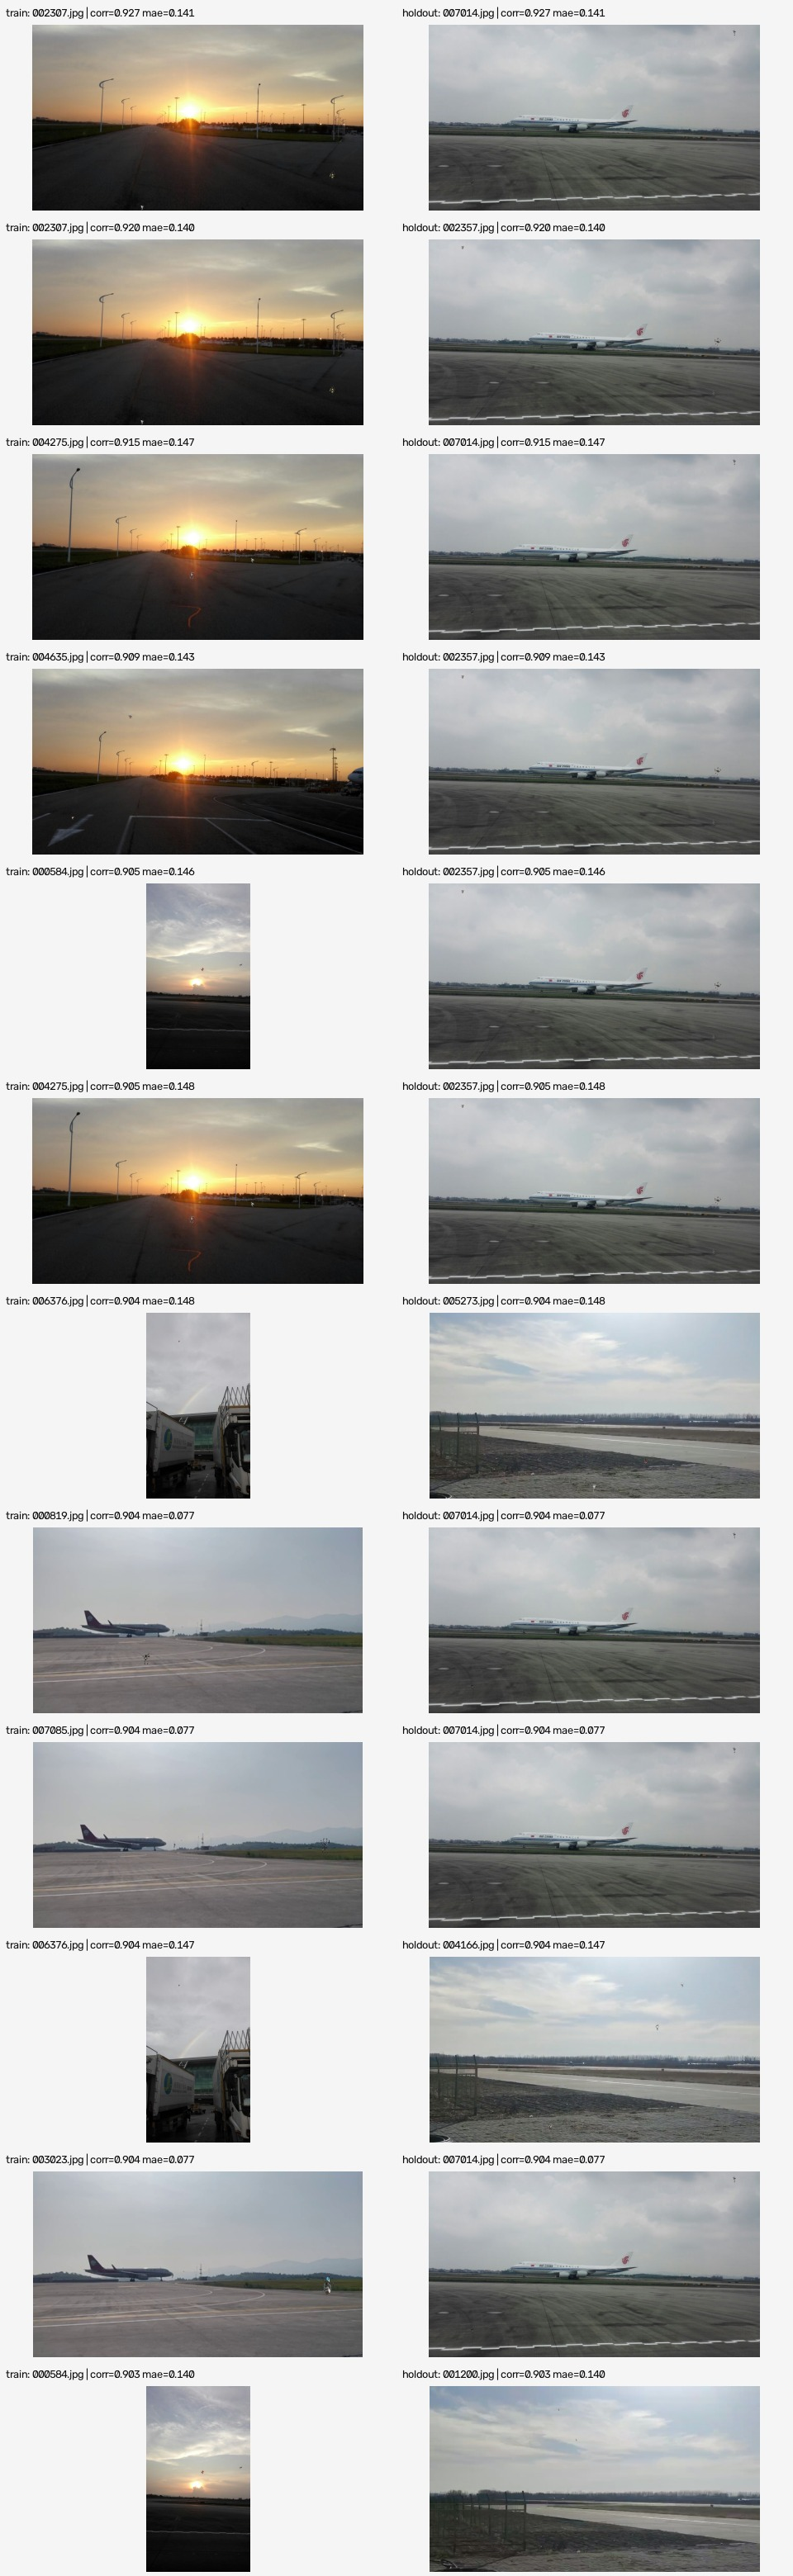

In [5]:
from IPython.display import Image, display
display(Image(filename=str(audit_dir / 'sensitivity_pairs.jpg')))

## Takeaways

1. Freeze `scene-v1` for the first YOLO11s/YOLO11m comparison.
2. Never substitute the publisher split in that comparison.
3. Keep test untouched until model selection is complete.
4. Treat UB-SOD results as development evidence; use external negative and distant-drone videos for field claims.